# <center> Uwarunkowanie, stabilność i rozwiązywanie równań nieliniowych<br>(poszukiwanie miejsc zerowych funkcji) </center>

# Uwarunkowanie i stabilność


***Zadanie 1. Czy wyznaczanie miejsc zerowych wielomianu może być zadaniem dobrze/źle uwarunkowanym? (Wielomian Wilkinsona)***

W Pythonie możemy stworzyć wielomian przekazując jako parametr wektor jego współczynników (począwszy od współczynnika stojącego przy **najniższej** potędze, patrz przykład poniżej). Proszę korzystać z modułu *numpy.polynomial* (zamiast *poly1d*).
* Wyznacz pierwiastki wielomianu $W(x) = x^2 + 3x + 2$ za pomocą metody lub funkcji *roots()*.
* Funkcja *Polynomial.fromroots* tworzy wielomian na podstawie listy przekazanych pierwiastków. Utwórz wielomian o następujących pierwiastkach $\{x_n = n, n = 1, 2, 3, . . . , 15\}$.
* Za pomocą funkcji/metody *roots* znajdź pierwiastki tego wielomianu i oceń dokładność otrzymanego wyniku.
* Do trzynastego elementu wektora współczynników wprowadź małe zaburzenie (np. rzędu $10^−5$) i znajdź pierwiastki wielomianu o zaburzonych współczynnikach. Wykreśl pierwiastki na płaszczyznie zespolonej. 
* Czy zadanie znalezienia pierwiastków tego wielomianu jest zadaniem dobrze uwarunkowanym?


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from numpy.polynomial import Polynomial
# Przykłady operacji na wielomianach
p = Polynomial([3, 2, 1]) # Od ostatniego współczynnika
print(p)
print(p.roots())
print(Polynomial.roots(p))




Pierwiastki x^2 + 3x + 2: [-2. -1.]
Błąd maksymalny (bez zaburzeń): 7.670357211608803e-06


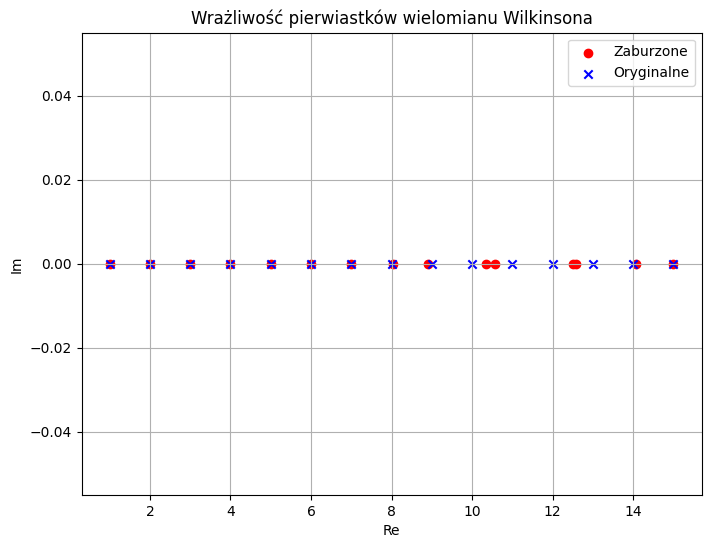

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

p1 = Polynomial([2, 3, 1])
print(f"Pierwiastki x^2 + 3x + 2: {p1.roots()}")

roots_orig = np.arange(1, 16)
p_wilkinson = Polynomial.fromroots(roots_orig)

roots_computed = p_wilkinson.roots()
print(f"Błąd maksymalny (bez zaburzeń): {np.max(np.abs(roots_computed - roots_orig))}")

coeffs_perturbed = p_wilkinson.coef.copy()
coeffs_perturbed[12] += 1e-5
p_perturbed = Polynomial(coeffs_perturbed)
roots_perturbed = p_perturbed.roots()

plt.figure(figsize=(8, 6))
plt.scatter(roots_perturbed.real, roots_perturbed.imag, color='red', label='Zaburzone')
plt.scatter(roots_orig, np.zeros_like(roots_orig), color='blue', marker='x', label='Oryginalne')
plt.title("Wrażliwość pierwiastków wielomianu Wilkinsona")
plt.xlabel("Re")
plt.ylabel("Im")
plt.legend()
plt.grid(True)
plt.show()

***Zadanie 2. Całka oznaczona***

Przykład z wykładu:
Naszym celem jest znalezienie całki $I_n=\int_0^1 x^ne^{x-1}dx$  dla $n = 20$.
* Na podstawie np. przybliżonych wykresów funkcji podcałkowej, proszę oszacować wartość tej całki oraz relację miedzy $I_n$ a $I_{n−1}$.
* Ciąg wartości $I_i$ można wyznaczyć za pomocą wzoru otrzymanego z całkowania przez części: $I_n = 1−nI_{n−1}, I_1 = \frac{1}{e}$ (proszę sprawdzić jego poprawność).
* Czy otrzymane wyniki są zgodne z przewidywaniami? Która operacja może powodować takie skutki?
* Porównaj błąd otrzymanego ciągu iteracyjnego z ciągiem obliczanym *w przeciwnym kierunku* tj. od $I_{20}$ do $I_1$. Proszę przyjąć, że $I_{20} = 0$.
* Jak duży jest błąd danej wejściowej ($I_{20}$) i ostatniego elementu ciągu ($I_1$)?
* Który algorytm jest stabilny, a który niestabilny?

In [2]:
import numpy as np

def solve_integral():
    # Rekurencja w przód: I_n = 1 - n * I_{n-1}
    # I_1 = 1 - 1/e
    i_val = 1 - (1 / np.e)
    forward_results = [i_val]
    for n in range(2, 21):
        i_val = 1 - n * i_val
        forward_results.append(i_val)
    
    # Rekurencja w tył: I_{n-1} = (1 - I_n) / n
    # Zakładamy I_20 = 0
    backward_results = [0.0] * 20
    current_i = 0.0 # I_20
    for n in range(20, 1, -1):
        current_i = (1 - current_i) / n
        backward_results[n-2] = current_i
        
    return forward_results, backward_results

fwd, bwd = solve_integral()
print(f"I_20 (w przód): {fwd[-1]}")
print(f"I_20 (w tył): {bwd[-1]} (to jest nasze założone 0, patrzmy na I_1)")
print(f"I_1 (w tył): {bwd[0]}")

I_20 (w przód): -6.428727457908358e+17
I_20 (w tył): 0.0 (to jest nasze założone 0, patrzmy na I_1)
I_1 (w tył): 0.36787944117144233


# Poszukiwanie miejsc zerowych

Dana jest funkcja $$f(x) = e^{-2x}+x^2-1$$

***Zadanie 1.***

Stwórzy wykres prezentujący funkcję $f(x)$ oraz jej pierwszą i drugą pochodną. Na podstawie spróbuj oszacować wartości pierwiastków równania $f(x) = 0$.

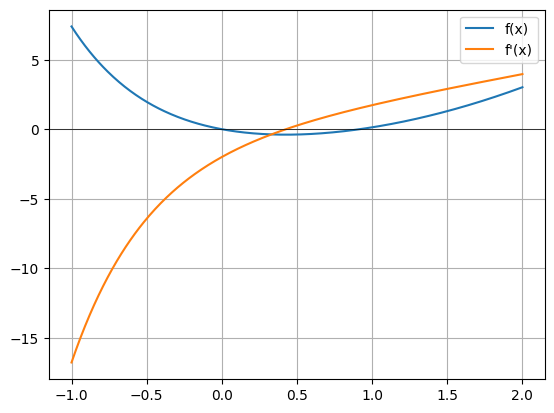

In [3]:
def f(x): return np.exp(-2*x) + x**2 - 1
def df(x): return -2*np.exp(-2*x) + 2*x
def ddf(x): return 4*np.exp(-2*x) + 2

x_vals = np.linspace(-1, 2, 400)
plt.plot(x_vals, f(x_vals), label='f(x)')
plt.plot(x_vals, df(x_vals), label="f'(x)")
plt.axhline(0, color='black', lw=0.5)
plt.legend()
plt.grid(True)
plt.show()

***Zadanie 2.***

Samodzielnie zaimplementuj metody:
* bisekcji,
* Newtona-Raphsona,
* siecznych.

Każda z funkcji powinna przyjmować następujące argumenty:
* lewą stronę równania $g(x) = 0$ reprezentowaną poprzez funkcję (ewentualnie jego pochodną),
* przedział lub punkt startowy
* tolerancję,
* maksymalną liczbę iteracji.

i zwracać:
* znaleziony pierwiastek,
* liczbę iteracji.

W jaki sposób sprawdzić warunek stopu? Czy kryterium stopu polegające na kontynuacji iteracji dopóki $x_{i+1}\neq x_i$ jest prawidłowe (bezpieczne)?

In [5]:
def bisekcja(f, a, b, tol, max_iter):
    if f(a) * f(b) > 0: return None, 0
    iters = 0
    while (b - a) / 2 > tol and iters < max_iter:
        mid = (a + b) / 2
        if f(mid) == 0: return mid, iters
        if f(a) * f(mid) < 0: b = mid
        else: a = mid
        iters += 1
    return (a + b) / 2, iters

def newton(f, df, x0, tol, max_iter):
    x = x0
    for i in range(max_iter):
        fx = f(x)
        if abs(fx) < tol: return x, i
        dfx = df(x)
        if dfx == 0: break
        x_new = x - fx / dfx
        if abs(x_new - x) < tol: return x_new, i+1
        x = x_new
    return x, max_iter

def sieczne(f, x0, x1, tol, max_iter):
    for i in range(max_iter):
        fx0, fx1 = f(x0), f(x1)
        if abs(fx1) < tol: return x1, i
        if fx1 - fx0 == 0: break
        x_new = x1 - fx1 * (x1 - x0) / (fx1 - fx0)
        if abs(x_new - x1) < tol: return x_new, i+1
        x0, x1 = x1, x_new
    return x1, max_iter

***Zadanie 3.***

Wykorzystaj stworzone w zadaniu 2. metody do znalezienia miejsc zerowych funkcji $f(x)$ z dokładnością $\epsilon = 10^{-6}$. Porównaj liczby iteracji niezbędnych do znalezienia pierwiastka. Która metoda sprawdziła się najlepiej? Która wypada najgorzej? Czy odpowiedni dobór przedziału może przyspieszyć proces rozwiązywania? Eksperyment przeprowadź dla wszystkich miejsc zerowych $f(x)$.


In [ ]:
import numpy as np
import pandas as pd

f = lambda x: np.exp(-2*x) + x**2 - 1
df = lambda x: -2*np.exp(-2*x) + 2*x

def bisekcja_v2(f, a, b, tol):
    history = []
    while (b - a) / 2 > tol:
        mid = (a + b) / 2
        history.append(mid)
        if f(a) * f(mid) < 0: b = mid
        else: a = mid
    return history

def newton_v2(f, df, x0, tol):
    history = [x0]
    x = x0
    while True:
        x_new = x - f(x) / df(x)
        history.append(x_new)
        if abs(x_new - x) < tol: break
        x = x_new
    return history

def sieczne_v2(f, x0, x1, tol):
    history = [x0, x1]
    while True:
        f_x0, f_x1 = f(history[-2]), f(history[-1])
        x_new = history[-1] - f_x1 * (history[-1] - history[-2]) / (f_x1 - f_x0)
        history.append(x_new)
        if abs(x_new - history[-2]) < tol: break
    return history

eps = 1e-6

hist_bis_1 = bisekcja_v2(f, -0.5, 0.4, eps)
hist_new_1 = newton_v2(f, df, -0.5, eps)
hist_sec_1 = sieczne_v2(f, -0.5, 0.4, eps)


hist_bis_2 = bisekcja_v2(f, 0.5, 1.5, eps)
hist_new_2 = newton_v2(f, df, 1.5, eps)
hist_sec_2 = sieczne_v2(f, 0.5, 1.5, eps)

# Tabela wyników
data = {
    "Metoda": ["Bisekcja", "Newton", "Sieczne"],
    "Iteracje (x≈0)": [len(hist_bis_1), len(hist_new_1), len(hist_sec_1)],
    "Iteracje (x≈0.91)": [len(hist_bis_2), len(hist_new_2), len(hist_sec_2)]
}
print(pd.DataFrame(data))

     Metoda  Iteracje (x≈0)  Iteracje (x≈0.91)
0  Bisekcja              19                 19
1    Newton               7                  6
2   Sieczne              12                  9


***Zadanie 4.***

Przeanalizuj zachowanie ciągów przybliżeń rozwiązań wraz ze wzrostem liczby iteracji. Przedstaw wyniki w postaci wykresu i dokonaj ich analizy.

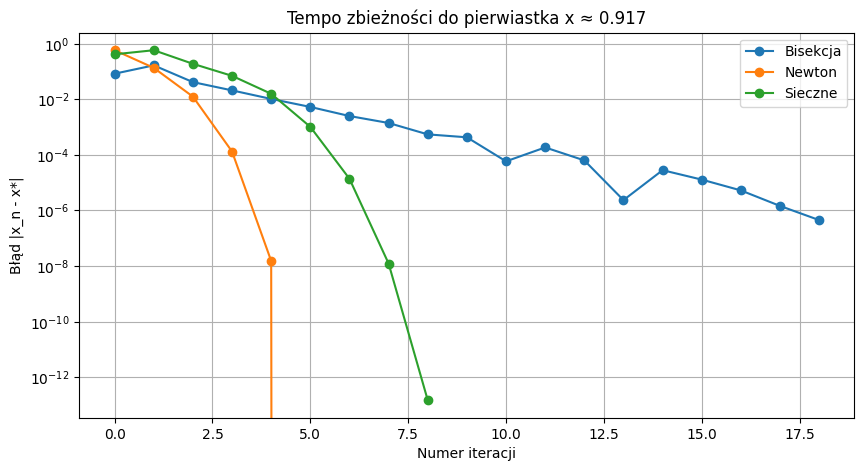

In [ ]:
import matplotlib.pyplot as plt

def plot_convergence(histories, titles, target_root):
    plt.figure(figsize=(10, 5))
    for hist, label in histories:
        errors = [abs(x - target_root) for x in hist]
        plt.semilogy(errors, marker='o', label=label) 
    plt.title(f"Tempo zbieżności do pierwiastka x ≈ {target_root:.3f}")
    plt.xlabel("Numer iteracji")
    plt.ylabel("Błąd |x_n - x*|")
    plt.legend()
    plt.grid(True, which="both", ls="-")
    plt.show()

root2 = hist_new_2[-1]
plot_convergence([
    (hist_bis_2, "Bisekcja"),
    (hist_new_2, "Newton"),
    (hist_sec_2, "Sieczne")
], "Zbieżność", root2)